R_max = 1, alpha = 0.1
Sum of calculated probability = 1.0000000000
Pr[  0] = 3.266668e-01
Pr[  1] = 2.908408e-01
Pr[  2] = 2.069535e-01
Pr[  3] = 1.097425e-01
Pr[  4] = 4.514350e-02
Pr[  5] = 1.510059e-02
Pr[  6] = 4.249931e-03
Pr[  7] = 1.031817e-03
Pr[  8] = 2.201969e-04
Pr[  9] = 4.191312e-05
Pr[ 10] = 7.199169e-06
Pr[ 11] = 1.126527e-06
Pr[ 12] = 1.618688e-07
Pr[ 13] = 2.150045e-08
Pr[ 14] = 2.655066e-09
Pr[ 15] = 3.063316e-10
R_max = 1, alpha = 0.3
Sum of calculated probability = 1.0000000000
Pr[  0] = 3.266668e-01
Pr[  1] = 2.908408e-01
Pr[  2] = 2.069535e-01
Pr[  3] = 1.097425e-01
Pr[  4] = 4.514350e-02
Pr[  5] = 1.510059e-02
Pr[  6] = 4.249931e-03
Pr[  7] = 1.031817e-03
Pr[  8] = 2.201969e-04
Pr[  9] = 4.191312e-05
Pr[ 10] = 7.199169e-06
Pr[ 11] = 1.126527e-06
Pr[ 12] = 1.618688e-07
Pr[ 13] = 2.150045e-08
Pr[ 14] = 2.655066e-09
Pr[ 15] = 3.063316e-10
R_max = 1, alpha = 0.5
Sum of calculated probability = 1.0000000000
Pr[  0] = 3.266668e-01
Pr[  1] = 2.908408e-01
Pr[  2] = 2.06

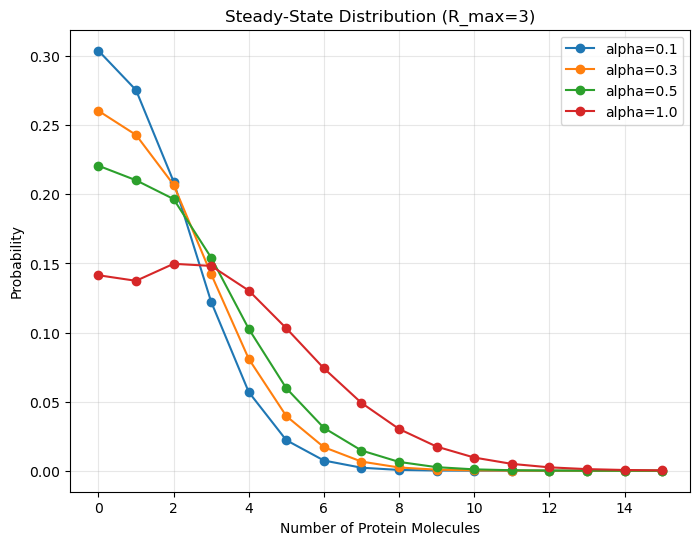

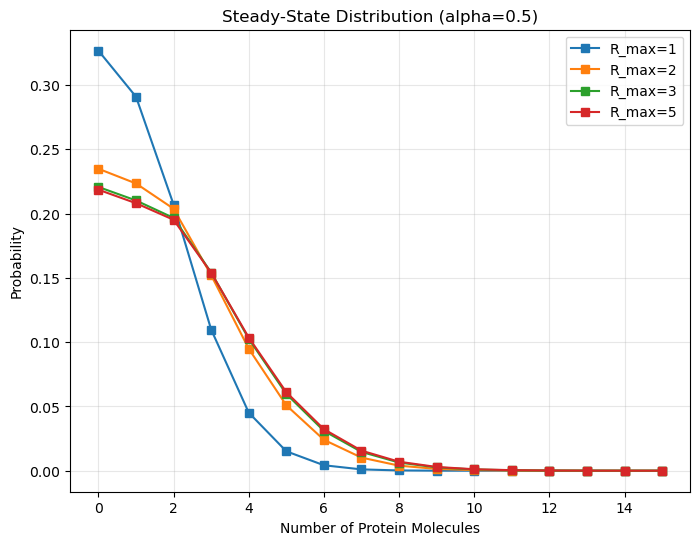

In [2]:
from scipy.linalg import inv
import numpy as np
import math
import matplotlib.pyplot as plt
from pathlib import Path


def C_finite(D_list, r_max):
    max_order = len(D_list)
    sample_D = D_list[0]
    C_list = [None] + [
        np.zeros_like(sample_D, dtype=float)
        for _ in range(r_max)
    ]

    for r in range(1, r_max + 1):
        Cr = np.zeros_like(sample_D, dtype=float)
        for n in range(r, max_order + 1):
            Cr += math.comb(n, r) * D_list[n - 1]
        C_list[r] = Cr

    return C_list


def D_finite(D0, D_list):
    N = D0.shape[0]
    D_tem = np.sum(D_list, axis=0)
    D_tem += D0

    for i in range(N):
        s = 0
        for j in range(N):
            if j != i:
                s += D_tem[i, j]
        D_tem[i, i] = -s

    return D_tem


def Binomial_Moments(D, C_list, pi, M_max=100, delta=1):
    pi = np.asarray(pi).reshape(1, -1)
    N = D.shape[0]
    ones = np.ones((N, 1))

    Z_list = [np.eye(N)]
    B_list = [1.0]

    I_N = np.eye(N)
    r_cut = len(C_list) - 1

    for m in range(1, M_max + 1):
        S = np.zeros((N, N), dtype=float)

        upper = min(m, r_cut)
        for i in range(1, upper + 1):
            C_i = C_list[i]
            if C_i is not None:
                S += Z_list[m - i] @ C_i

        M = m * delta * I_N - D
        M_inv = inv(M, overwrite_a=False)

        Z_m = S @ M_inv
        Z_list.append(Z_m)

        B_m = pi @ Z_m @ ones
        B_list.append(B_m[0, 0])

    return B_list


def stable_comb(n, k, b):
    if b < 0:
        raise ValueError(
            f"Scaling factor b must be non-negative. Received: {b}"
        )

    if b == 0:
        return 0.0

    if not isinstance(n, int) or not isinstance(k, int):
        raise TypeError(
            f"Both n and k must be integers. "
            f"Received types: n={type(n)}, k={type(k)}"
        )

    if n < 0:
        raise ValueError(f"n must be non-negative. Received: {n}")

    if k < 0 or k > n:
        return 0.0

    log_comb = (
        math.lgamma(n + 1)
        - math.lgamma(k + 1)
        - math.lgamma(n - k + 1)
    )
    log_total = log_comb + math.log(abs(b))

    if log_total < -700:
        return 0.0

    return math.copysign(math.exp(log_total), b)


def solve_one_case(
    D0,
    D1,
    alpha,
    R_max,
    delta=1,
    M_max=200,
    N_max=21
):
    N = D0.shape[0]

    D_list = []

    for n in range(1, R_max + 1):
        D_list.append(
            alpha ** (n - 1) / math.factorial(n) * D1
        )

    D = D_finite(D0, D_list)

    DT = D.T.copy()
    DT[0, :] = np.ones(N)

    b = np.zeros(N)
    b[0] = 1.0

    pi = np.linalg.solve(DT, b).reshape(1, N)

    C_list = C_finite(D_list, R_max)

    binomial_moments = Binomial_Moments(
        D,
        C_list,
        pi,
        M_max,
        delta
    )

    prob = np.zeros(N_max)

    for n in range(N_max):
        total = 0.0
        sign = 1

        for j in range(n, M_max + 1):
            term = (
                sign
                * stable_comb(
                    j,
                    n,
                    binomial_moments[j]
                )
            )
            total += term
            sign = -sign

        prob[n] = total

    return {
        "alpha": alpha,
        "R_max": R_max,
        "D_list": D_list,
        "D": D,
        "pi": pi,
        "C_list": C_list,
        "binomial_moments": np.array(binomial_moments),
        "prob": prob,
        "prob_sum": np.sum(prob)
    }


D0 = np.array([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
], dtype=float)

D1 = np.array([
    [0.2, 0.2, 0.1, 0.8],
    [0.2, 0.2, 0.1, 0.8],
    [0.1, 0.1, 0.1, 0.0],
    [0.8, 0.8, 0.0, 0.8]
], dtype=float)

delta = 1
M_max = 1000
N_max = 16

R_max_list = [1, 2, 3, 5]
alpha_list = [0.1, 0.3, 0.5, 1.0]

output_dir = Path("fig3_data")
output_dir.mkdir(parents=True, exist_ok=True)

results = {}

for R_max in R_max_list:
    for alpha in alpha_list:
        res = solve_one_case(
            D0,
            D1,
            alpha,
            R_max,
            delta=delta,
            M_max=M_max,
            N_max=N_max
        )

        results[(R_max, alpha)] = res

        print("=" * 60)
        print(f"R_max = {R_max}, alpha = {alpha}")
        print(
            f"Sum of calculated probability = "
            f"{res['prob_sum']:.10f}"
        )

        for i, x in enumerate(res["prob"]):
            print(f"Pr[{i:3d}] = {float(x):.6e}")

        file_path = (
            output_dir
            / f"PMF_R{R_max}_alpha{alpha:.2f}.npy"
        )

        np.save(file_path, res["prob"])

fixed_R = 3

plt.figure(figsize=(8, 6), dpi=100)

for alpha in alpha_list:
    prob = results[(fixed_R, alpha)]["prob"]
    plt.plot(
        range(len(prob)),
        prob,
        marker="o",
        label=f"alpha={alpha}"
    )

plt.title(f"Steady-State Distribution (R_max={fixed_R})")
plt.xlabel("Number of Protein Molecules")
plt.ylabel("Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

fixed_alpha = 0.5

plt.figure(figsize=(8, 6), dpi=100)

for R_max in R_max_list:
    prob = results[(R_max, fixed_alpha)]["prob"]
    plt.plot(
        range(len(prob)),
        prob,
        marker="s",
        label=f"R_max={R_max}"
    )

plt.title(
    f"Steady-State Distribution (alpha={fixed_alpha})"
)
plt.xlabel("Number of Protein Molecules")
plt.ylabel("Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()